In [1]:
#Standard libraries and ML tools
import pandas as pd
import numpy as np
import warnings
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

C:\Users\egorv\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#Load MovieLens dataset
movies = pd.read_csv('movies.csv', sep = ',')
ratings = pd.read_csv('ratings.csv', sep = ',')

#One-hot encode movie genres
genres = movies.drop(['title'], axis = 1)
genres = pd.concat(
    [genres[['movieId']], genres['genres'].str.get_dummies('|')],
    axis=1
)

In [3]:
#Split ratings into training and test sets
train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

In [4]:
#Compute movie-level statistics (mean rating, number of ratings)
movie_stats = train_ratings.groupby('movieId').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = [
    'avg_movie_rating',
    'num_movie_ratings'
]

In [5]:
#Compute user-level statistics (mean rating, number of ratings)
user_stats = train_ratings.groupby('userId').agg({
    'rating': ['mean', 'count']
})

user_stats.columns = [
    'avg_user_rating',
    'num_user_ratings'
]

In [6]:
#Merge features into final training set
train = train_ratings.merge(user_stats, on='userId')
train = train.merge(movie_stats, on='movieId')
train = train.merge(genres, on='movieId', how='left')
train = train.drop(['timestamp'], axis = 1)

#Merge features into test set
test = test_ratings.merge(user_stats, on='userId', how='left')
test = test.merge(movie_stats, on='movieId', how='left')
test = test.merge(genres, on='movieId', how='left')
test = test.drop(['timestamp'], axis = 1)

In [7]:
#Fill missing values using global statistics
global_mean = train_ratings['rating'].mean()

test['avg_user_rating'] = test['avg_user_rating'].fillna(global_mean)
test['avg_movie_rating'] = test['avg_movie_rating'].fillna(global_mean)

test['num_user_ratings'] = test['num_user_ratings'].fillna(0)
test['num_movie_ratings'] = test['num_movie_ratings'].fillna(0)

In [8]:
#Define features and target variable
X_train = train.drop(['rating', 'userId', 'movieId'], axis = 1)
y_train = train['rating']

X_test = test.drop(['rating', 'userId', 'movieId'], axis = 1)
y_test = test['rating']

In [9]:
#Initialize metrics storage
metrics = pd.DataFrame(columns = ['LinearRegression', 'Decision Tree',
                              'Random Forest', 'GradientBoostingRegressor'],
                       index = ['MAE', 'MSE', 'RMSE', 'R2'])

#Define regression models for comparison
models = {
    "LinearRegression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

#Train and evaluate each model
for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    metrics.loc[['MAE', 'MSE', 'RMSE', 'R2'], name] = [mae, mse, rmse, r2]

metrics

,LinearRegression,Decision Tree,Random Forest,GradientBoostingRegressor
MAE,0.686876,0.691448,0.689735,0.684551
MSE,0.805822,0.817529,0.823495,0.802866
RMSE,0.897676,0.904173,0.907466,0.896028
R2,0.267462,0.25682,0.251396,0.270149


In [10]:
#Plot metric comparison across models
def metric_graph(metric_name):
  plt.figure(figsize=(8,5))
  metrics.loc[metric_name].plot(kind='bar')

  plt.title(f'{metric_name} comparison')
  plt.ylabel(metric_name)
  plt.grid(axis='y')
  plt.xticks(rotation=45)

  plt.show()

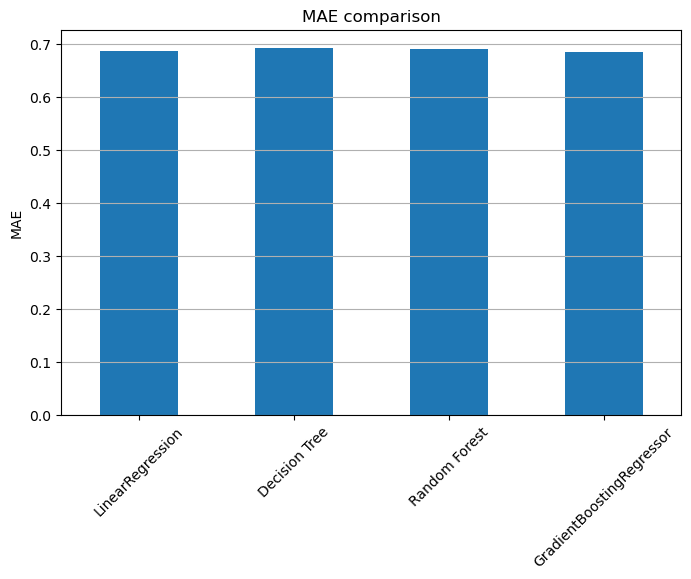

In [11]:
metric_graph('MAE')

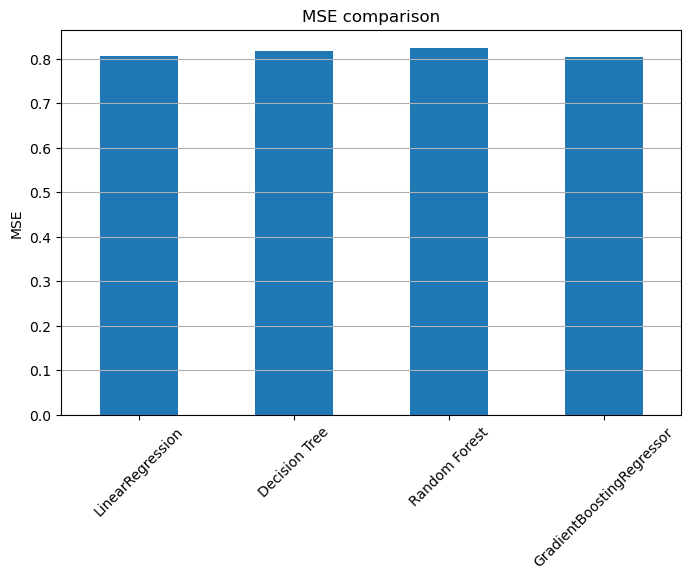

In [12]:
metric_graph('MSE')

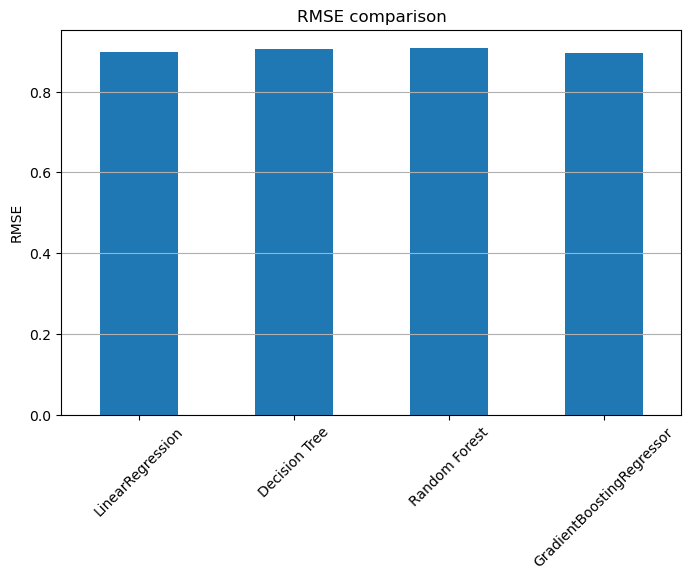

In [13]:
metric_graph('RMSE')

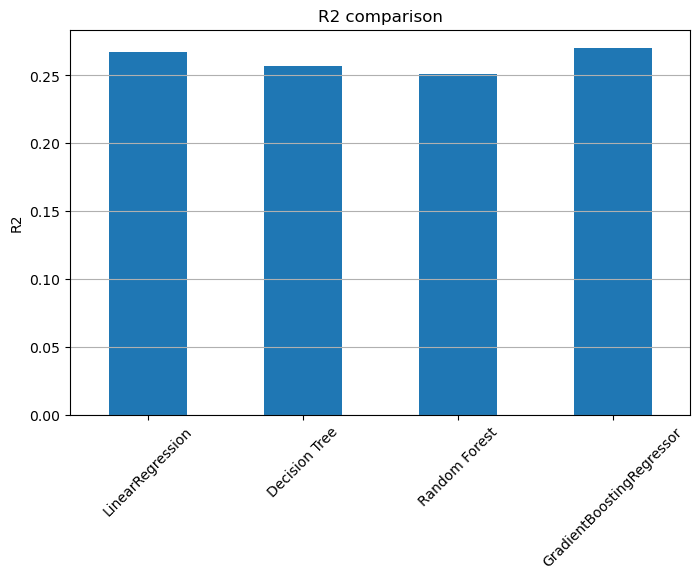

In [14]:
metric_graph('R2')

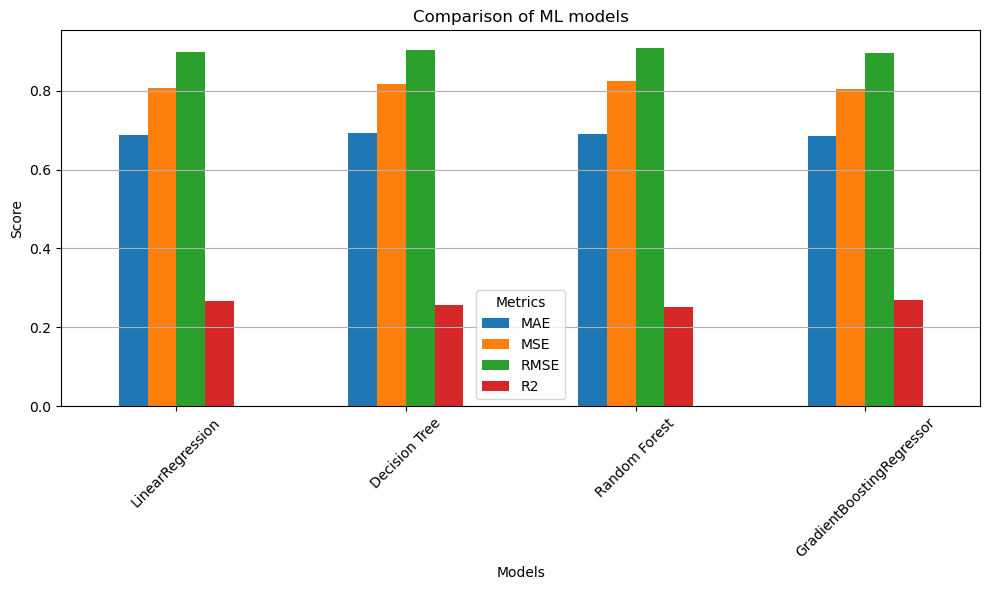

In [15]:
metrics.T.plot(kind='bar', figsize=(10, 6))

plt.title('Comparison of ML models')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.legend(title='Metrics')
plt.tight_layout()
plt.show()